***Caricamento Dataset e Librerie***

In [1]:
#Carico le librerie
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Import OK")

Import OK


In [2]:
# Carico il file CSV in un DataFrame di Pandas
df_estratti = pd.read_csv("TicketEstrazione090326.csv")
print("=== DATAFRAME CARICATO CORRETTAMENTE ===")

# visualizzo le prime 5 righe del DataFrame
print("=== PRIME 5 RIGHE DATAFRAME ===")
df_estratti.head()

=== DATAFRAME CARICATO CORRETTAMENTE ===
=== PRIME 5 RIGHE DATAFRAME ===


,url_ticket,case_number,oggetto,descrizione,priorita_finale,priorita_iniziale_cliente,area,tipologia_intervento,articolo,modulo_sw,reparto,data_creazione,data_risoluzione,conversazione
0,https://maia.zucchettihc.it/index.php?module=C...,245378,I: Notifica Change Request in Maia - cliente [...,costo da richiedere al cliente euro 1.950\ngra...,P3,NaN,NaN,assistenza_ordinaria,NaN,NaN,Commerciale,2025-06-11 12:45:01,2025-06-12 14:34:52,"admin: <div class=""elementToProof"" style=""font..."
1,https://maia.zucchettihc.it/index.php?module=C...,246139,come liberare la scadenza di un incasso client...,Buongiorno\nVolevo capire come liberare una sc...,P3,NaN,ciclo_passivo,assistenza_ordinaria,Contabilità Economica 2.0,AMM - Economica 2.0,Assistenza Sipcar,2025-06-18 12:37:55,2025-07-11 08:01:00,"CLIENTE: <p><span style=""font-family:Roboto;"">..."
2,https://maia.zucchettihc.it/index.php?module=C...,265147,Richiesta informazioni su bonifico con segno n...,"Buongiorno,\navrei bisogno di chiedere un'info...",P3,NaN,ciclo_passivo,assistenza_ordinaria,Contabilità Economica 2.0,AMM - Economica 2.0,Assistenza Sipcar,2025-12-09 13:49:34,2025-12-11 08:18:00,"CLIENTE: <p><span style=""font-family:Roboto;"">..."
3,https://maia.zucchettihc.it/index.php?module=C...,262895,Bilancio di previsione,"Buongiorno,\nsto cercando di accedere a ""Bilan...",P2,NaN,area_personale,assistenza_ordinaria,BILANCIO DI PREVISIONE,SO-Pers-Bilancio di Previsione,HRSC Payroll,2025-11-19 11:07:44,2025-11-19 13:09:49,"CLIENTE: <p><span style=""font-family:Roboto;"">..."
4,https://maia.zucchettihc.it/index.php?module=C...,220018,Richiesta formulazione offerta per CIVILIA NEX...,"\nCiao,\n \nVi chiedo cortesemente di formular...",P3,NaN,NaN,NaN,NaN,NaN,Commerciale,2024-11-11 10:01:01,2024-11-20 09:04:17,"admin: <div class=""WordSection1"">\n<p class=""M..."


***Esplorazione Caratteristiche Dataset***

In [3]:
# visualizzo le informazioni sul DataFrame (n.Righe/Colonne/Nan/TipoDato)
print("=== INFO DATAFRAME ===")
df_estratti.info()

=== INFO DATAFRAME ===
<class 'pandas.DataFrame'>
RangeIndex: 58412 entries, 0 to 58411
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   url_ticket                 58412 non-null  str  
 1   case_number                58412 non-null  int64
 2   oggetto                    58412 non-null  str  
 3   descrizione                58302 non-null  str  
 4   priorita_finale            58412 non-null  str  
 5   priorita_iniziale_cliente  7011 non-null   str  
 6   area                       52563 non-null  str  
 7   tipologia_intervento       56077 non-null  str  
 8   articolo                   52531 non-null  str  
 9   modulo_sw                  52605 non-null  str  
 10  reparto                    58173 non-null  str  
 11  data_creazione             58412 non-null  str  
 12  data_risoluzione           58249 non-null  str  
 13  conversazione              58410 non-null  str  
dtypes: int64(1

=== VALORI MANCANTI ===
                  colonna  null_count  null_pct
priorita_iniziale_cliente       51401      88.0
                 articolo        5881      10.1
                     area        5849      10.0
                modulo_sw        5807       9.9
     tipologia_intervento        2335       4.0
                  reparto         239       0.4
         data_risoluzione         163       0.3
              descrizione         110       0.2
               url_ticket           0       0.0
              case_number           0       0.0
          priorita_finale           0       0.0
                  oggetto           0       0.0
           data_creazione           0       0.0
            conversazione           2       0.0


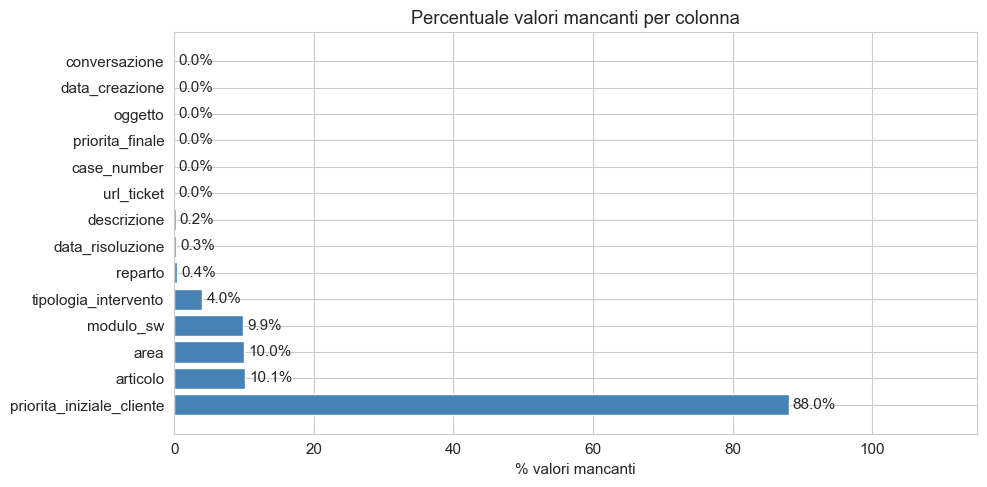

In [4]:
# VALORI MANCANTI
null_counts = df_estratti.isnull().sum()
null_pct = (null_counts / len(df_estratti) * 100).round(1)

null_df = pd.DataFrame({
    'colonna': null_counts.index,
    'null_count': null_counts.values,
    'null_pct': null_pct.values
}).sort_values('null_pct', ascending=False)

print("=== VALORI MANCANTI ===")
print(null_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(null_df['colonna'], null_df['null_pct'], color='steelblue')
ax.set_xlabel('% valori mancanti')
ax.set_title('Percentuale valori mancanti per colonna')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

***Analisi Distribuzioni e Pattern Dataset***

=== DISTRIBUZIONE PRIORITÀ INIZIO (4 valori unici) ===
priorita_iniziale_cliente
P1    4976
P2    1548
P3     456
P4      31


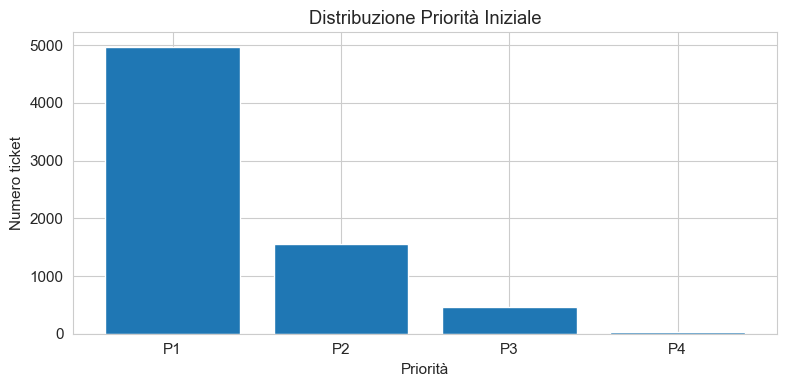

In [5]:
# DISTRIBUZIONE PRIORITA INIZIALE
priority_counts_inizio = df_estratti['priorita_iniziale_cliente'].value_counts().sort_index()

print(f"=== DISTRIBUZIONE PRIORITÀ INIZIO ({df_estratti['priorita_iniziale_cliente'].nunique()} valori unici) ===")
print(priority_counts_inizio.to_string())

# Grafico distribuzione Priorità
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(priority_counts_inizio.index, priority_counts_inizio.values)
ax.set_title('Distribuzione Priorità Iniziale')
ax.set_xlabel('Priorità')
ax.set_ylabel('Numero ticket')
plt.tight_layout()
plt.show()

=== DISTRIBUZIONE PRIORITÀ (4 valori unici) ===
priorita_finale
P1     8132
P2    16998
P3    31809
P4     1473


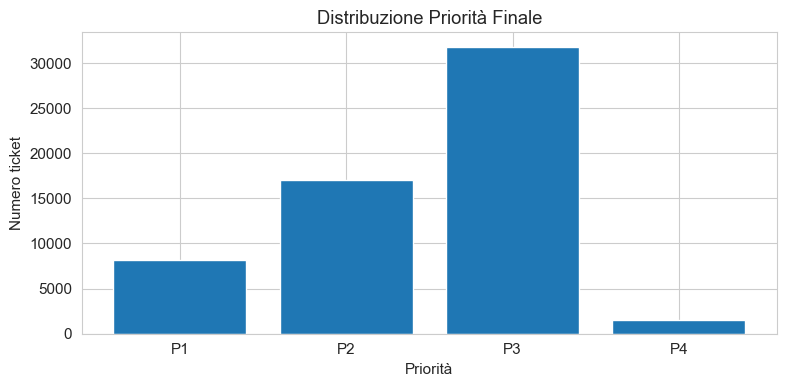

In [6]:
# DISTRIBUZIONE PRIORITÀ FINALE
priority_counts = df_estratti['priorita_finale'].value_counts().sort_index()

print(f"=== DISTRIBUZIONE PRIORITÀ ({df_estratti['priorita_finale'].nunique()} valori unici) ===")
print(priority_counts.to_string())

# Grafico distribuzione Priorità
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(priority_counts.index, priority_counts.values)
ax.set_title('Distribuzione Priorità Finale')
ax.set_xlabel('Priorità')
ax.set_ylabel('Numero ticket')
plt.tight_layout()
plt.show()

In [7]:
# Conteggio delle variazioni di ogni combinazione di cambio di priority
variazioni = df_estratti[df_estratti['priorita_iniziale_cliente'].notna()].groupby(
    ['priorita_iniziale_cliente', 'priorita_finale']
).size().reset_index(name='n').sort_values('n', ascending=False)

print("=== VARIAZIONI PRIORITÀ (da cliente a finale) ===")
print(variazioni.to_string(index=False))


=== VARIAZIONI PRIORITÀ (da cliente a finale) ===
priorita_iniziale_cliente priorita_finale    n
                       P1              P2 3413
                       P1              P3 1480
                       P2              P3 1329
                       P3              P4  170
                       P3              P2  166
                       P2              P1  107
                       P3              P1  100
                       P2              P4   86
                       P1              P4   56
                       P1              P1   27
                       P2              P2   26
                       P4              P3   21
                       P3              P3   20
                       P4              P2    8
                       P4              P1    2


=== DISTRIBUZIONE AREA (17 valori unici) ===
area
area_personale                     14263
ciclo_passivo                      10993
ciclo_attivo                        9236
area_sanitaria                      8748
rendicontazione_flussi              2859
protocollo_documentale_delibere     2581
area_sistemistica                   1109
sistema381                          1006
6                                    842
area_territoriale                    537
protocollo_delibere                  228
business_intelligence                149
1                                      4
5                                      3
4                                      3
3                                      1
flussi_regionali                       1


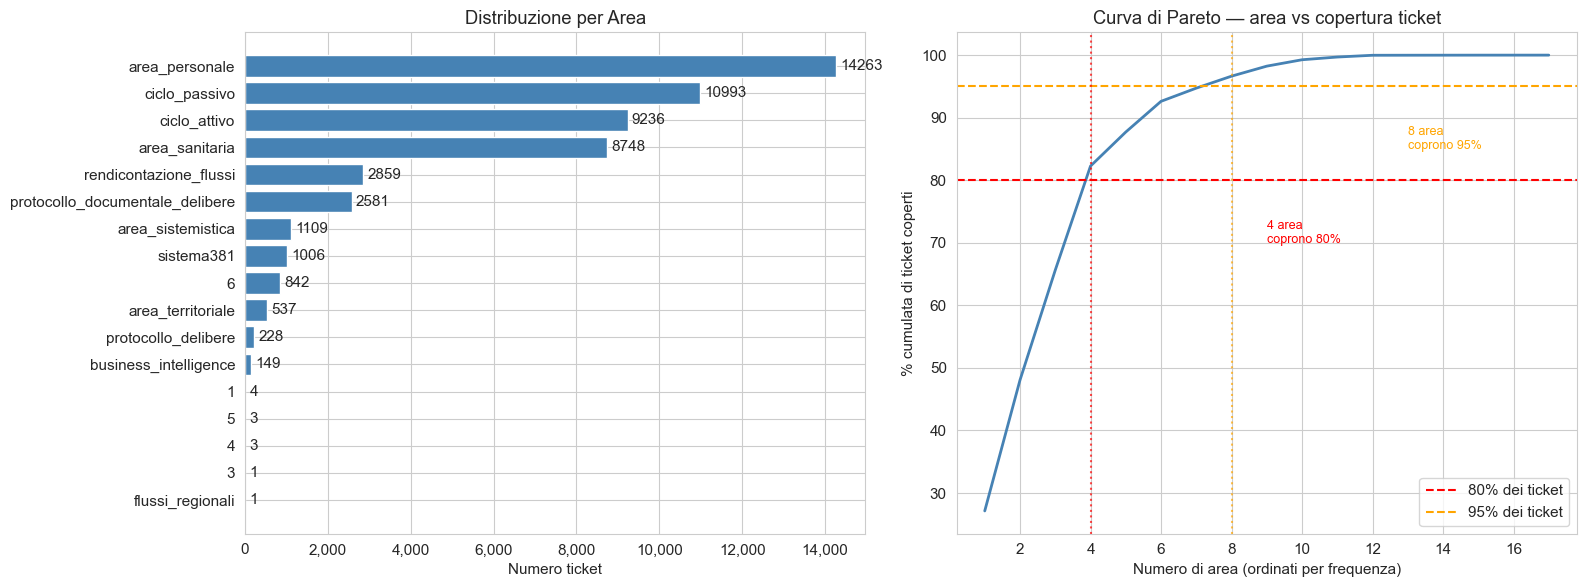

Aree totali distinte: 17
Aree per coprire 80% dei ticket: 4
Aree per coprire 95% dei ticket: 8


In [8]:
# DISTRIBUZIONE AREA 
top_n = 20
area_counts = df_estratti['area'].value_counts()
top_area = area_counts.head(top_n)
top20 = area_counts.head(20)

print(f"=== DISTRIBUZIONE AREA ({df_estratti['area'].nunique()} valori unici) ===")
print(area_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico con distribuzioni Area
ax = axes[0]
bars = ax.barh(area_counts.index[::-1], area_counts.values[::-1], color='steelblue')
ax.set_xlabel('Numero ticket')
ax.set_title('Distribuzione per Area')
ax.bar_label(bars, fmt='%d', padding=3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Grafico 2: Curva di Pareto
ax2 = axes[1]
cumulative = area_counts.cumsum() / area_counts.sum() * 100
ax2.plot(range(1, len(cumulative)+1), cumulative.values, color='steelblue', linewidth=2)
ax2.axhline(80, color='red', linestyle='--', label='80% dei ticket')
ax2.axhline(95, color='orange', linestyle='--', label='95% dei ticket')

# Trova i punti di taglio
idx_80 = (cumulative >= 80).idxmax()
idx_95 = (cumulative >= 95).idxmax()
n_80 = area_counts.index.get_loc(idx_80) + 1
n_95 = area_counts.index.get_loc(idx_95) + 1

ax2.axvline(n_80, color='red', linestyle=':', alpha=0.7)
ax2.axvline(n_95, color='orange', linestyle=':', alpha=0.7)
ax2.set_xlabel('Numero di area (ordinati per frequenza)')
ax2.set_ylabel('% cumulata di ticket coperti')
ax2.set_title('Curva di Pareto — area vs copertura ticket')
ax2.legend()
ax2.annotate(f'{n_80} area\ncoprono 80%', xy=(n_80, 80), xytext=(n_80+5, 70),
             fontsize=9, color='red')
ax2.annotate(f'{n_95} area\ncoprono 95%', xy=(n_95, 95), xytext=(n_95+5, 85),
             fontsize=9, color='orange')

plt.tight_layout()
plt.show()

# Stampa anche i numeri chiave
print(f"Aree totali distinte: {len(area_counts)}")
print(f"Aree per coprire 80% dei ticket: {n_80}")
print(f"Aree per coprire 95% dei ticket: {n_95}")

=== AREA vs PRIORITÀ (% per riga) ===
priorita_finale                    P1    P2    P3    P4
area                                                   
6                                20.8  15.2  61.2   2.9
area_personale                   24.4  25.8  47.6   2.2
area_sanitaria                   11.3  30.7  54.2   3.8
area_sistemistica                26.0  24.5  46.3   3.2
area_territoriale                14.3  39.9  44.7   1.1
ciclo_attivo                     11.7  36.7  49.0   2.6
ciclo_passivo                     6.7  39.7  51.6   2.0
protocollo_delibere              19.3  38.6  41.7   0.4
protocollo_documentale_delibere  17.5  27.2  53.1   2.2
rendicontazione_flussi           21.1  37.8  39.2   1.9
sistema381                        8.2  11.8  67.5  12.5


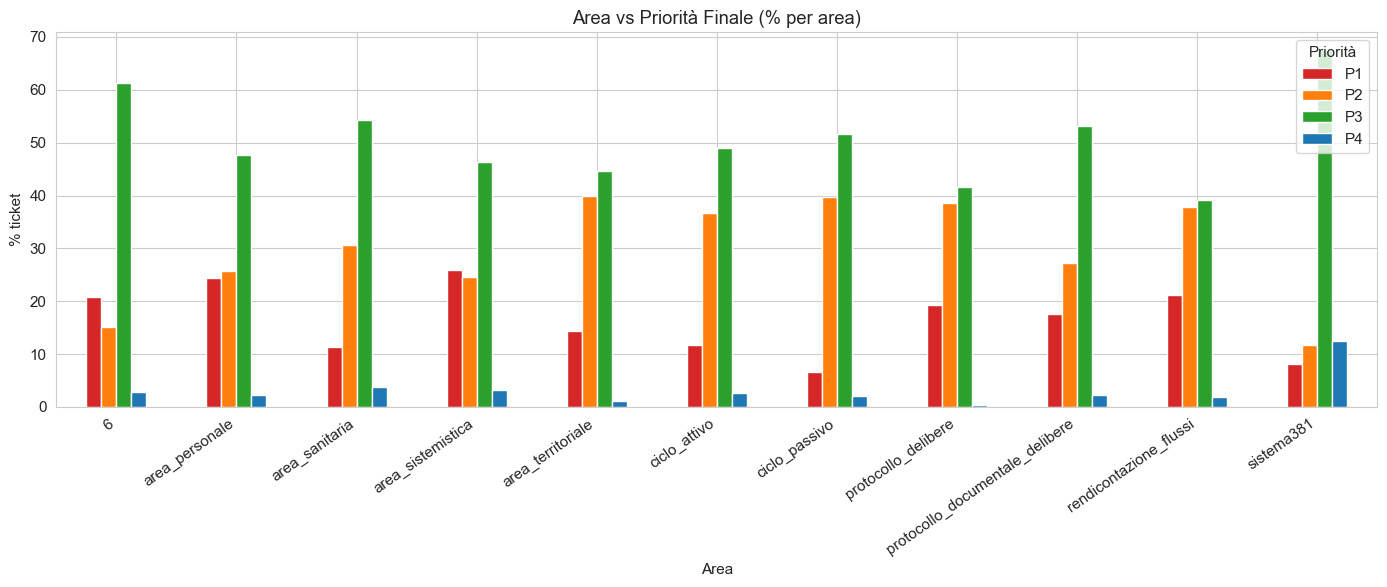

In [9]:
# CROSS-TAB: AREA vs PRIORITÀ
# Usa aree con almeno 200 ticket
aree_valide = df_estratti['area'].value_counts()
aree_valide = aree_valide[aree_valide >= 200].index.tolist()

cross_area = pd.crosstab(
    df_estratti[df_estratti['area'].isin(aree_valide)]['area'],
    df_estratti[df_estratti['area'].isin(aree_valide)]['priorita_finale'],
    normalize='index'
).round(3) * 100

print("=== AREA vs PRIORITÀ (% per riga) ===")
print(cross_area.round(1))

cross_area.plot(kind='bar', figsize=(14, 6),
                color={'P1':'#d62728','P2':'#ff7f0e','P3':'#2ca02c','P4':'#1f77b4'})
plt.title('Area vs Priorità Finale (% per area)')
plt.xlabel('Area')
plt.ylabel('% ticket')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Priorità')
plt.tight_layout()
plt.show()

=== DISTRIBUZIONE MODULO SW (240 valori unici, mostro solo i primi 20) ===
modulo_sw
PER-Rilevazione Presenze 2.0                 4871
SO-Pers-Stipendi                             4727
AMM - Economica 2.0                          4426
CSS - Cartella Socio Sanitaria 2.0           4068
OSP - Contabilità Utenti 2.0                 2945
SW1_Ciclo attivo                             2919
SW1_Contabilità generale                     2126
SW1_CU4 - Dossier Sanitario Elettronico      1622
PER-Portale Personale 2.0                    1533
Supporto Sistemistico                        1090
SW1_Lapis                                    1070
PER-Rilevazione Presenze 1.0                  965
OSP - Fatturazione Elettronica                949
SW1_CUWEB - Dossier Sanitario Elettronico     842
CSS - CSS 1.0                                 832
Flussi Reg. - Scheda SOSIA 2.0                733
Contabilità Economica - Solo Reg.IVA PA-      678
PER-Turni 1.0                                 666
AMM - Protocoll

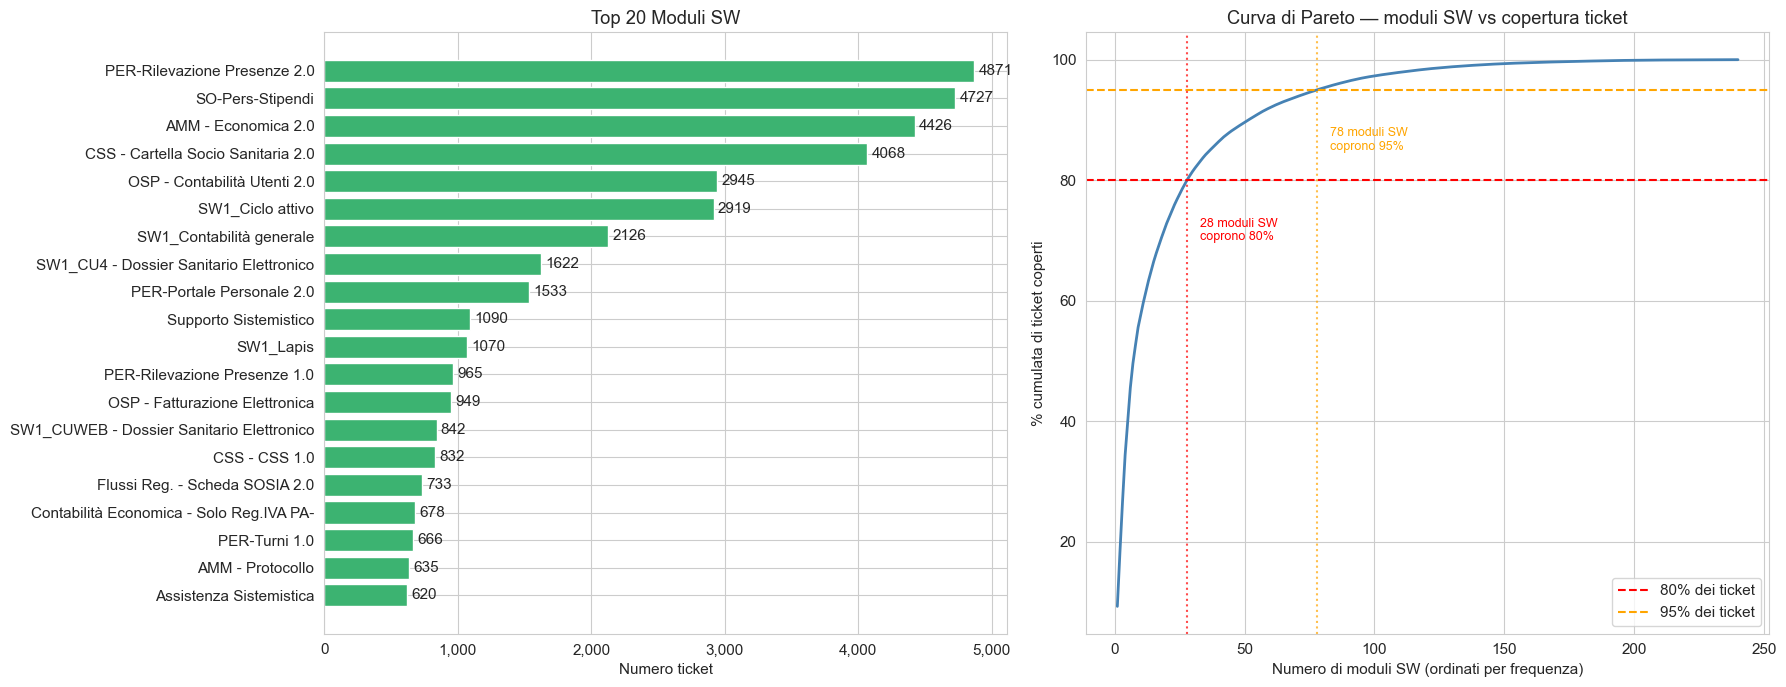

Moduli SW totali distinti: 240
Moduli SW per coprire 80% dei ticket: 28
Moduli SW per coprire 95% dei ticket: 78


In [10]:
# DISTRIBUZIONE MODULO SW
ModuloSW_counts = df_estratti['modulo_sw'].value_counts()
top20 = ModuloSW_counts.head(20)

print(f"=== DISTRIBUZIONE MODULO SW ({df_estratti['modulo_sw'].nunique()} valori unici, mostro solo i primi {len(top20)}) ===")
print(top20.to_string())

# Create subplots for both charts
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Grafico Distribuzione top 20 ModuliSW
ax1 = axes[0]
bars = ax1.barh(top20.index[::-1], top20.values[::-1], color='mediumseagreen')
ax1.set_xlabel('Numero ticket')
ax1.set_title('Top 20 Moduli SW')
ax1.bar_label(bars, fmt='%d', padding=3)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Grafico 2: Curva di Pareto
ax2 = axes[1]
cumulative = ModuloSW_counts.cumsum() / ModuloSW_counts.sum() * 100
ax2.plot(range(1, len(cumulative)+1), cumulative.values, color='steelblue', linewidth=2)
ax2.axhline(80, color='red', linestyle='--', label='80% dei ticket')
ax2.axhline(95, color='orange', linestyle='--', label='95% dei ticket')

# Trova i punti di taglio
idx_80 = (cumulative >= 80).idxmax()
idx_95 = (cumulative >= 95).idxmax()
n_80 = ModuloSW_counts.index.get_loc(idx_80) + 1
n_95 = ModuloSW_counts.index.get_loc(idx_95) + 1

ax2.axvline(n_80, color='red', linestyle=':', alpha=0.7)
ax2.axvline(n_95, color='orange', linestyle=':', alpha=0.7)
ax2.set_xlabel('Numero di moduli SW (ordinati per frequenza)')
ax2.set_ylabel('% cumulata di ticket coperti')
ax2.set_title('Curva di Pareto — moduli SW vs copertura ticket')
ax2.legend()
ax2.annotate(f'{n_80} moduli SW\ncoprono 80%', xy=(n_80, 80), xytext=(n_80+5, 70),
             fontsize=9, color='red')
ax2.annotate(f'{n_95} moduli SW\ncoprono 95%', xy=(n_95, 95), xytext=(n_95+5, 85),
             fontsize=9, color='orange')

plt.tight_layout()
plt.show()

# Stampa anche i numeri chiave
print(f"Moduli SW totali distinti: {len(ModuloSW_counts)}")
print(f"Moduli SW per coprire 80% dei ticket: {n_80}")
print(f"Moduli SW per coprire 95% dei ticket: {n_95}")


=== TOP 10 MODULI SW vs PRIORITÀ (% per riga) ===
priorita_finale                            P1    P2    P3   P4
modulo_sw                                                     
AMM - Economica 2.0                       5.0  40.2  53.0  1.8
CSS - Cartella Socio Sanitaria 2.0        9.7  28.9  58.1  3.3
OSP - Contabilità Utenti 2.0              8.8  26.5  61.0  3.8
PER-Portale Personale 2.0                17.5  20.3  59.8  2.3
PER-Rilevazione Presenze 2.0             21.3  22.2  53.6  2.9
SO-Pers-Stipendi                         30.3  33.1  35.1  1.5
SW1_CU4 - Dossier Sanitario Elettronico  13.7  29.5  51.8  5.0
SW1_Ciclo attivo                         14.4  47.6  36.0  2.0
SW1_Contabilità generale                  9.7  43.0  45.4  1.8
Supporto Sistemistico                    26.0  24.6  46.4  3.0


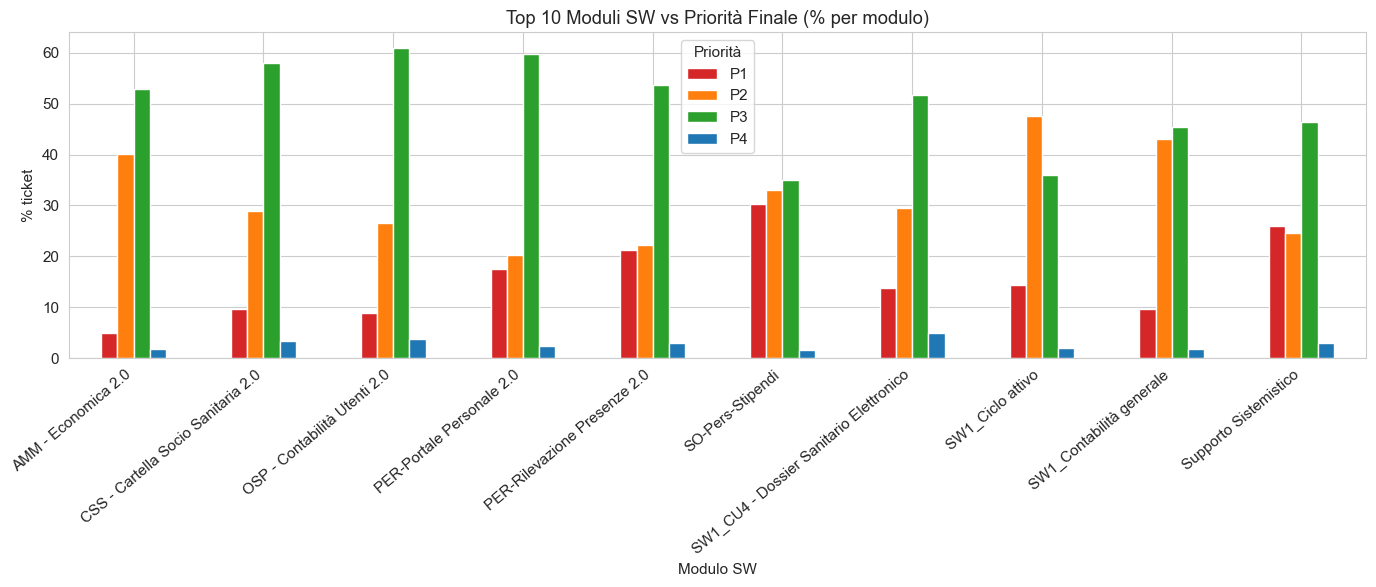

In [11]:
# CROSS-TAB: TOP 10 MODULI SW vs PRIORITÀ
top10_moduli = df_estratti['modulo_sw'].value_counts().head(10).index

cross_mod = pd.crosstab(
    df_estratti[df_estratti['modulo_sw'].isin(top10_moduli)]['modulo_sw'],
    df_estratti[df_estratti['modulo_sw'].isin(top10_moduli)]['priorita_finale'],
    normalize='index'
).round(3) * 100

print("=== TOP 10 MODULI SW vs PRIORITÀ (% per riga) ===")
print(cross_mod.round(1))

cross_mod.plot(kind='bar', figsize=(14, 6),
               color={'P1':'#d62728','P2':'#ff7f0e','P3':'#2ca02c','P4':'#1f77b4'})
plt.title('Top 10 Moduli SW vs Priorità Finale (% per modulo)')
plt.xlabel('Modulo SW')
plt.ylabel('% ticket')
plt.xticks(rotation=40, ha='right')
plt.legend(title='Priorità')
plt.tight_layout()
plt.show()

=== DISTRIBUZIONE articolo (649 valori unici, mostro solo i primi 20) ===
articolo
Gestione Stipendi                                   4225
Contabilità Economica 2.0                           2893
Ciclo attivo                                        2791
Contabilità Utenti 2.0                              2486
Rilevazione Presenze 2.0                            2248
Cartella Socio Sanitaria 2.0                        1812
Contabilità generale                                1735
DSE - Dossier Sanitario Elettronico                 1568
Supporto Sistemistico                               1085
PORTALE PERSONALE 2.0                               1062
Rilevazione Presenze                                 937
RIL. PRESENZE 2.0 fino a 100 dipendenti              885
Fatturazione Elettronica Completa                    871
CARTELLA SOCIO SANITARIA (2.0) Fino a 150 utenti     679
Contabilità Economica                                671
Cartella-Area Sanitaria                              644
RIL. 

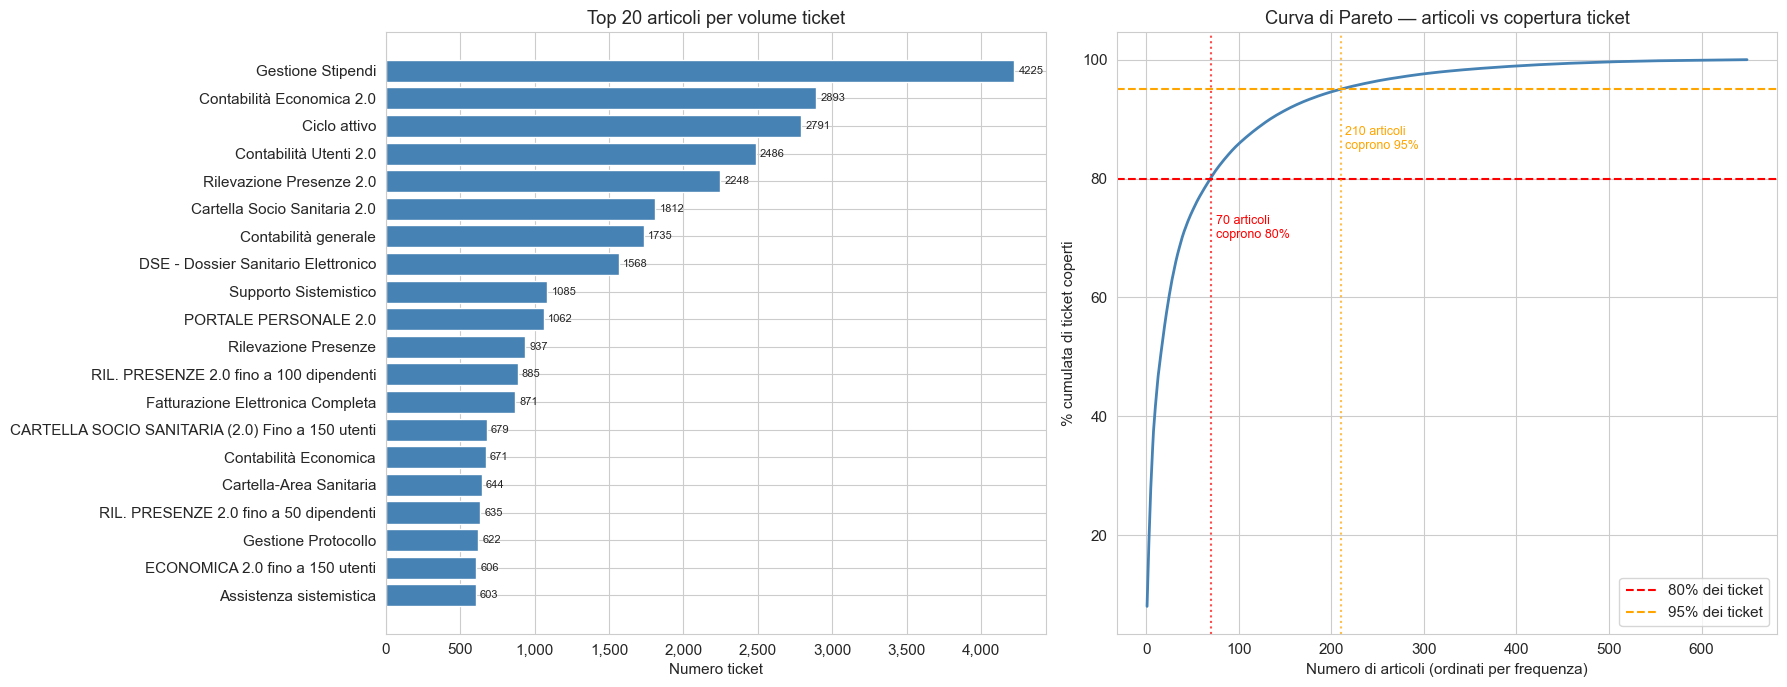

Articoli totali distinti: 649
Articoli per coprire 80% dei ticket: 70
Articoli per coprire 95% dei ticket: 210


In [12]:
# DISTRIBUZIONE ARTICOLI
articolo_counts = df_estratti['articolo'].value_counts()
top20 = articolo_counts.head(20)

print(f"=== DISTRIBUZIONE articolo ({df_estratti['articolo'].nunique()} valori unici, mostro solo i primi {len(top20)}) ===")
print(top20.to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Grafico distribuzione top 20 articolo
ax1 = axes[0]
bars = ax1.barh(top20.index[::-1], top20.values[::-1], color='steelblue')
ax1.set_xlabel('Numero ticket')
ax1.set_title(f'Top {len(top20)} articoli per volume ticket')
ax1.bar_label(bars, padding=3, fontsize=8)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Grafico 2: Curva di Pareto
ax2 = axes[1]
cumulative = articolo_counts.cumsum() / articolo_counts.sum() * 100
ax2.plot(range(1, len(cumulative)+1), cumulative.values, color='steelblue', linewidth=2)
ax2.axhline(80, color='red', linestyle='--', label='80% dei ticket')
ax2.axhline(95, color='orange', linestyle='--', label='95% dei ticket')

# Trova i punti di taglio
idx_80 = (cumulative >= 80).idxmax()
idx_95 = (cumulative >= 95).idxmax()
n_80 = articolo_counts.index.get_loc(idx_80) + 1
n_95 = articolo_counts.index.get_loc(idx_95) + 1

ax2.axvline(n_80, color='red', linestyle=':', alpha=0.7)
ax2.axvline(n_95, color='orange', linestyle=':', alpha=0.7)
ax2.set_xlabel('Numero di articoli (ordinati per frequenza)')
ax2.set_ylabel('% cumulata di ticket coperti')
ax2.set_title('Curva di Pareto — articoli vs copertura ticket')
ax2.legend()
ax2.annotate(f'{n_80} articoli\ncoprono 80%', xy=(n_80, 80), xytext=(n_80+5, 70),
             fontsize=9, color='red')
ax2.annotate(f'{n_95} articoli\ncoprono 95%', xy=(n_95, 95), xytext=(n_95+5, 85),
             fontsize=9, color='orange')

plt.tight_layout()
plt.show()

# Stampa anche i numeri chiave
print(f"Articoli totali distinti: {len(articolo_counts)}")
print(f"Articoli per coprire 80% dei ticket: {n_80}")
print(f"Articoli per coprire 95% dei ticket: {n_95}")

=== TOP 10 ARTICOLI vs PRIORITÀ (% per riga) ===
priorita_finale                        P1    P2    P3   P4
articolo                                                  
Cartella Socio Sanitaria 2.0         10.5  25.8  59.4  4.4
Ciclo attivo                         14.7  47.4  36.0  1.8
Contabilità Economica 2.0             5.3  41.8  51.1  1.8
Contabilità Utenti 2.0                9.0  27.6  60.0  3.5
Contabilità generale                  9.9  41.5  46.5  2.1
DSE - Dossier Sanitario Elettronico  13.8  29.0  52.4  4.9
Gestione Stipendi                    30.8  33.9  33.9  1.4
PORTALE PERSONALE 2.0                19.1  19.9  58.5  2.5
Rilevazione Presenze 2.0             23.3  23.7  50.5  2.5
Supporto Sistemistico                26.1  24.7  46.2  3.0


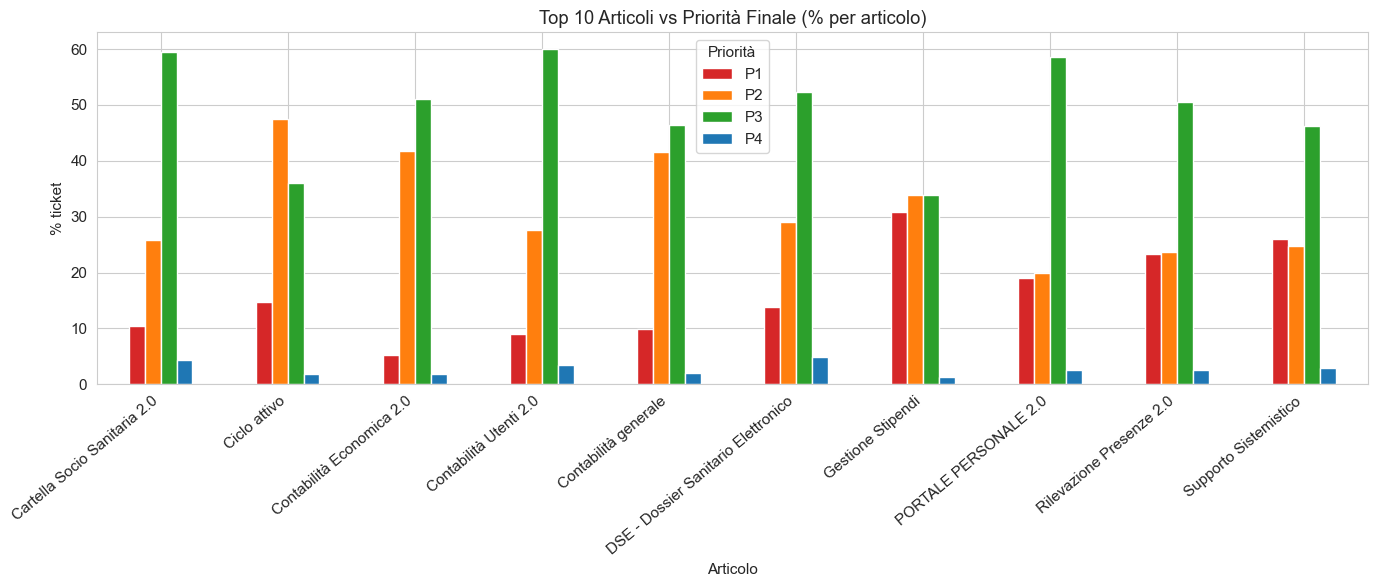

In [13]:
# CROSS-TAB: TOP 10 MODULI SW vs PRIORITÀ
top10_articoli = df_estratti['articolo'].value_counts().head(10).index

cross_mod = pd.crosstab(
    df_estratti[df_estratti['articolo'].isin(top10_articoli)]['articolo'],
    df_estratti[df_estratti['articolo'].isin(top10_articoli)]['priorita_finale'],
    normalize='index'
).round(3) * 100

print("=== TOP 10 ARTICOLI vs PRIORITÀ (% per riga) ===")
print(cross_mod.round(1))

cross_mod.plot(kind='bar', figsize=(14, 6),
               color={'P1':'#d62728','P2':'#ff7f0e','P3':'#2ca02c','P4':'#1f77b4'})
plt.title('Top 10 Articoli vs Priorità Finale (% per articolo)')
plt.xlabel('Articolo')
plt.ylabel('% ticket')
plt.xticks(rotation=40, ha='right')
plt.legend(title='Priorità')
plt.tight_layout()
plt.show()

=== REPARTI (35 valori unici) - Top 15 ===
reparto
Assistenza Sipcar          14911
HRSC Delivery&Support       8666
Assistenza Cartella         5813
HRSC Payroll                5623
Consulenti c.attivo         4645
Commerciale                 3572
Consulenti c.passivo        3293
Consulenti DSE              2592
Amm. Digitale               2492
Hardware                    2029
Reparto 381                 1006
Attivazione Portale          913
SW1_sistemistico             613
Consulenti territoriali      535
Monitoraggio Servizi         440


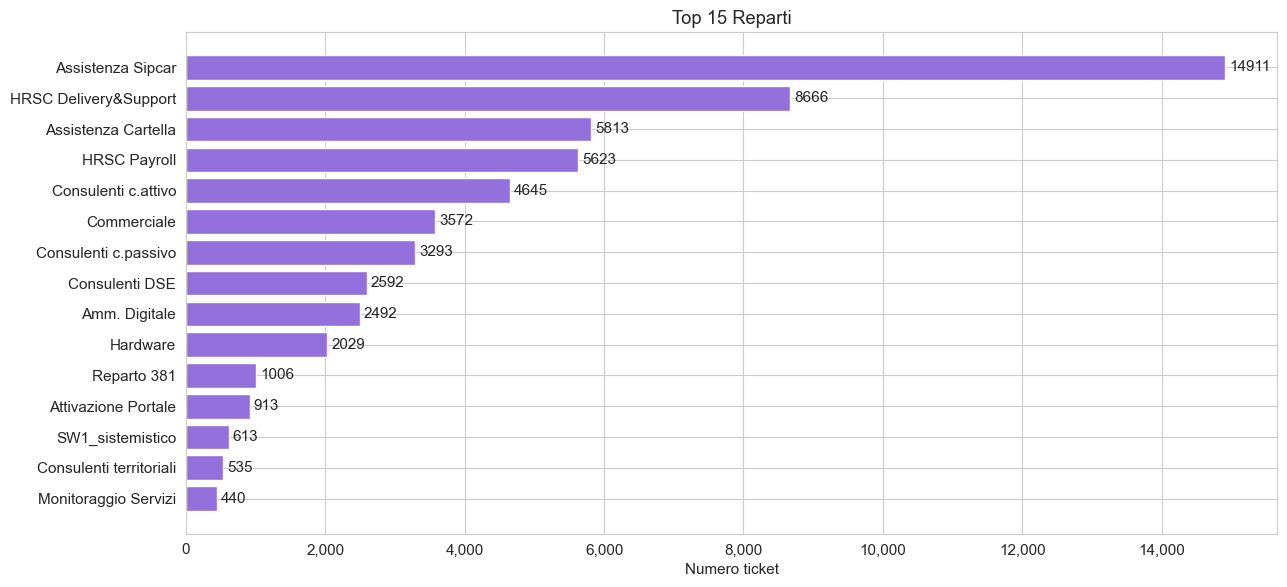

In [14]:
#  DISTRIBUZIONE REPARTO
reparto_counts = df_estratti['reparto'].value_counts()

print(f"=== REPARTI ({df_estratti['reparto'].nunique()} valori unici) - Top 15 ===")
print(reparto_counts.head(15).to_string())

# Grafico distribuzione top 15 Reparti
top15 = reparto_counts.head(15)
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color='mediumpurple')
ax.set_xlabel('Numero ticket')
ax.set_title('Top 15 Reparti')
ax.bar_label(bars, fmt='%d', padding=3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

***Analisi Temporale***

Ticket con tempo di risoluzione valido: 57,021 / 58,412

=== TEMPO DI RISOLUZIONE (ore) ===
count    57021.0
mean       182.5
std        559.4
min          0.0
25%          2.4
50%         23.4
75%        116.9
max       8716.0
Name: ore_risoluzione, dtype: float64

Mediana: 23.4 ore (1.0 giorni)


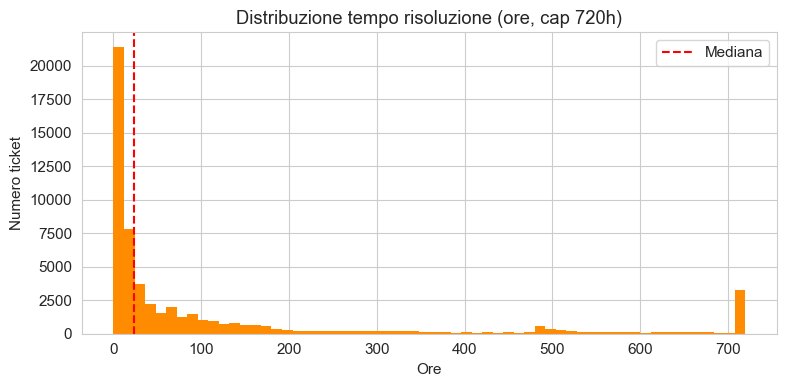

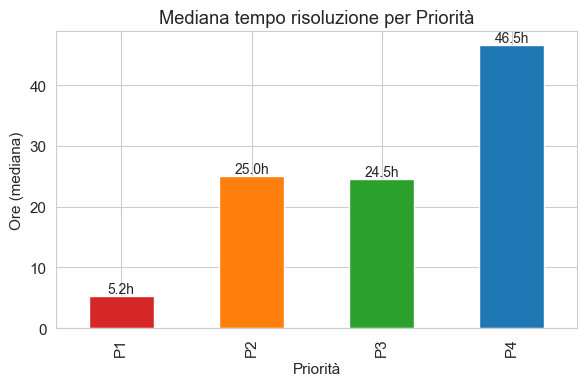

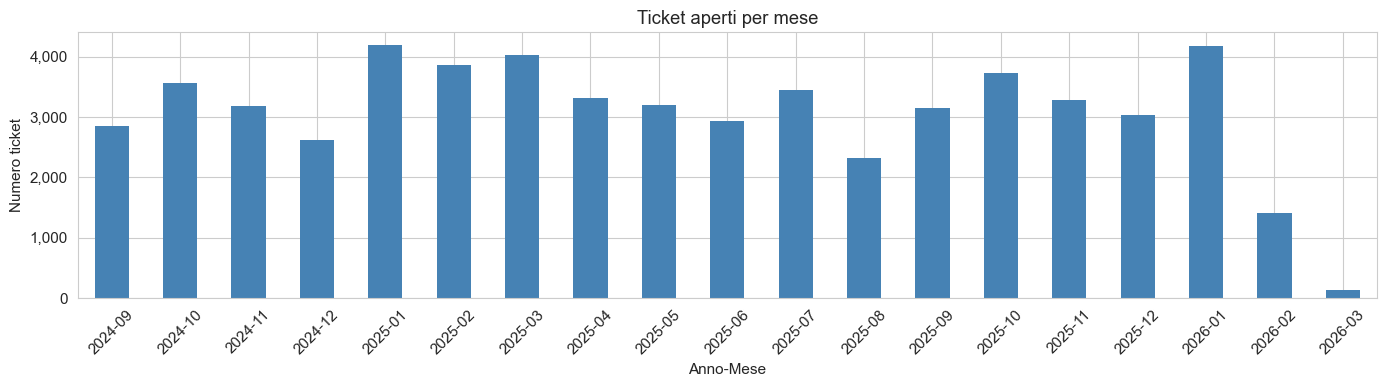

In [15]:
# ANALISI TEMPORALE
df_estratti['data_creazione'] = pd.to_datetime(df_estratti['data_creazione'], errors='coerce')
df_estratti['data_risoluzione'] = pd.to_datetime(df_estratti['data_risoluzione'], errors='coerce')

# Tempo di risoluzione in ore
df_estratti['ore_risoluzione'] = (
    (df_estratti['data_risoluzione'] - df_estratti['data_creazione'])
    .dt.total_seconds() / 3600
)

# Escludo valori negativi o assurdi (> 365 giorni)
df_valid = df_estratti[(df_estratti['ore_risoluzione'] > 0) & (df_estratti['ore_risoluzione'] < 365*24)]

print(f"Ticket con tempo di risoluzione valido: {len(df_valid):,} / {len(df_estratti):,}")
print("\n=== TEMPO DI RISOLUZIONE (ore) ===")
print(df_valid['ore_risoluzione'].describe().round(1))
print(f"\nMediana: {df_valid['ore_risoluzione'].median():.1f} ore ({df_valid['ore_risoluzione'].median()/24:.1f} giorni)")

# grafico distribuzione 
fig, ax = plt.subplots(figsize=(8,4))
df_valid['ore_risoluzione'].clip(upper=720).hist(bins=60, ax=ax, color='darkorange', edgecolor='none')
ax.set_title('Distribuzione tempo risoluzione (ore, cap 720h)')
ax.set_xlabel('Ore')
ax.set_ylabel('Numero ticket')
ax.axvline(df_valid['ore_risoluzione'].median(), color='red', linestyle='--', label='Mediana')
ax.legend()
plt.tight_layout()
plt.show()

# grafico mediana per priorità
mediana_ore = df_valid.groupby('priorita_finale')['ore_risoluzione'].median().sort_index()
fig, ax = plt.subplots(figsize=(6,4))
mediana_ore.plot(kind='bar', ax=ax, color=['#d62728','#ff7f0e','#2ca02c','#1f77b4'])
ax.set_title('Mediana tempo risoluzione per Priorità')
ax.set_xlabel('Priorità')
ax.set_ylabel('Ore (mediana)')
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{bar.get_height():.1f}h', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Andamento mensile dei ticket
df_estratti['anno_mese'] = df_estratti['data_creazione'].dt.to_period('M')
mensile = df_estratti.groupby('anno_mese').size()

fig, ax = plt.subplots(figsize=(14, 4))
mensile.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Ticket aperti per mese')
ax.set_xlabel('Anno-Mese')
ax.set_ylabel('Numero ticket')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

***Pulizia Testo e Analisi Troncamento***

In [16]:
# PULIZIA TESTO E ANALISI DESCRIZIONE
def pulisci_html(testo):
    """Rimuove tag HTML, entità e spazi multipli."""
    if not isinstance(testo, str):
        return ""
    testo = re.sub(r'<[^>]+>', ' ', testo)
    testo = re.sub(r'&[a-zA-Z0-9#]+;', ' ', testo)
    testo = re.sub(r'\s+', ' ', testo).strip()
    return testo

df_estratti['descrizione_pulita'] = df_estratti['descrizione'].apply(pulisci_html)
df_estratti['desc_n_char'] = df_estratti['descrizione_pulita'].str.len()
df_estratti['desc_n_parole'] = df_estratti['descrizione_pulita'].str.split().str.len()

print("=== STATISTICHE LUNGHEZZA DESCRIZIONE ===")
print(df_estratti[['desc_n_char', 'desc_n_parole']].describe().round(1))
print(f"\nDescrizioni vuote o quasi (< 5 parole): {(df_estratti['desc_n_parole'] < 5).sum():,}")
print(f"Descrizioni molto corte (< 10 parole):   {(df_estratti['desc_n_parole'] < 10).sum():,}")

=== STATISTICHE LUNGHEZZA DESCRIZIONE ===
       desc_n_char  desc_n_parole
count      58412.0        58412.0
mean         474.0           68.3
std          978.4          132.2
min            0.0            0.0
25%          192.0           27.0
50%          295.0           43.0
75%          460.0           68.0
max        65533.0         8673.0

Descrizioni vuote o quasi (< 5 parole): 504
Descrizioni molto corte (< 10 parole):   1,990


In [17]:
# Conteggio lunghezza conversazione
df_estratti['conversazione_pulita'] = df_estratti['conversazione'].apply(pulisci_html)
df_estratti['conv_n_char'] = df_estratti['conversazione_pulita'].str.len()
df_estratti['conv_n_parole'] = df_estratti['conversazione_pulita'].str.split().str.len()
# Visualizzo le statistiche di lunghezza della conversazione
print("=== STATISTICHE LUNGHEZZA CONVERSAZIONE ===")
print(df_estratti[['conv_n_char', 'conv_n_parole']].describe().round(1))
print(f"\nConversazioni vuote o quasi (< 5 parole): {(df_estratti['conv_n_parole'] < 5).sum():,}")
print(f"Conversazioni molto corte (< 10 parole):   {(df_estratti['conv_n_parole'] < 10).sum():,}")

=== STATISTICHE LUNGHEZZA CONVERSAZIONE ===
       conv_n_char  conv_n_parole
count      58412.0        58412.0
mean        4044.1          204.0
std        49531.5          229.5
min            0.0            0.0
25%          610.0           89.0
50%          971.0          144.0
75%         1612.0          239.0
max       999997.0        16083.0

Conversazioni vuote o quasi (< 5 parole): 93
Conversazioni molto corte (< 10 parole):   252


In [18]:
keywords = ['crash', 'blocco', 'errore', 'lento', 'non funziona', 'impossibile', 'fallito', 'urgente', 'immediato', 'non rispondere', 'risolvere subito', 'asap', 'il prima possibile', 'critico', 'grave', 'bloccante', 'disastroso']
for kw in keywords:
    df_estratti[f'kw_{kw}'] = df_estratti['descrizione_pulita'].str.contains(kw, case=False, na=False)
    cross_kw = pd.crosstab(df_estratti[f'kw_{kw}'], df_estratti['priorita_finale'], normalize='index') * 100
    print(f"\n=== Presenza parola chiave '{kw}' vs Priorità Finale ===")
    print(cross_kw.round(1))
    


=== Presenza parola chiave 'crash' vs Priorità Finale ===
priorita_finale    P1    P2    P3   P4
kw_crash                              
False            13.9  29.1  54.5  2.5
True             10.0  50.0  40.0  0.0

=== Presenza parola chiave 'blocco' vs Priorità Finale ===
priorita_finale    P1    P2    P3   P4
kw_blocco                             
False            13.9  29.1  54.5  2.5
True             23.7  32.6  42.4  1.3

=== Presenza parola chiave 'errore' vs Priorità Finale ===
priorita_finale    P1    P2    P3   P4
kw_errore                             
False            14.1  30.2  52.8  2.9
True             13.4  24.8  60.7  1.1

=== Presenza parola chiave 'lento' vs Priorità Finale ===
priorita_finale    P1    P2    P3   P4
kw_lento                              
False            13.9  29.1  54.5  2.5
True             20.2  30.3  48.6  0.9

=== Presenza parola chiave 'non funziona' vs Priorità Finale ===
priorita_finale    P1    P2    P3   P4
kw_non funziona                  

In [19]:
for kw in keywords:
    col = f'kw_{kw}'
    if col in df_estratti.columns:
        n_true = df_estratti[col].sum()
        print(f"'{kw}': {n_true} ticket")

'crash': 10 ticket
'blocco': 380 ticket
'errore': 12089 ticket
'lento': 109 ticket
'non funziona': 866 ticket
'impossibile': 543 ticket
'fallito': 426 ticket
'urgente': 2550 ticket
'immediato': 69 ticket
'non rispondere': 12 ticket
'risolvere subito': 2 ticket
'asap': 11 ticket
'il prima possibile': 215 ticket
'critico': 6 ticket
'grave': 177 ticket
'bloccante': 298 ticket
'disastroso': 0 ticket


In [20]:
# Lista delle parole/frasI da cercare
keywords_priorita = [
    'abbassare la priorità', 'alzare la priorità',
    'abbassato la priorità', 'alzato la priorità',
    'priorità è', 'priorità è stata',
    'priorità finale è', 'priorità finale è stata'
]

# Creazione della maschera True/False per la presenza di uno dei pattern
pattern = '|'.join(keywords_priorita)
mask = df_estratti['conversazione_pulita'].str.lower().str.contains(pattern, na=False)

# Conteggio e percentuali
num_conversazioni = mask.sum()
perc_conversazioni = mask.mean() * 100

print(f"Conversazioni con menzione priorità: {num_conversazioni:,} ({perc_conversazioni:.1f}%)")

# Esempio di conversazione (se esiste almeno un match)
if num_conversazioni > 0:
    print("\n=== ESEMPIO CONVERSAZIONE CON MENZIONE PRIORITÀ ===")
    print(df_estratti[mask]['conversazione_pulita'].iloc[0])

Conversazioni con menzione priorità: 59 (0.1%)

=== ESEMPIO CONVERSAZIONE CON MENZIONE PRIORITÀ ===
CLIENTE: Orario reperibilità contatto: lun.-ven. 09-16 Telefono: 0395320100 abbiamo scaricato l'app della css sui tablet da dare in dotazione ai medici e ci viene richiesto di inserire una password in impostazioni app --- Martina Soini: Buongiorno, Ecco le istruzioni per configurare la app sui nuovi dispositivi. 1. Accedi alla App, premi il bottone di configurazione in basso a sinistra. 2. Il programma chiederà una password: Febbraio2020 3. In root server impostare l’indirizzo di Sipcar2 (che vedete accedendo al programma dal pc) tralasciando la parte /cba/. Esempio: Se l’indirizzo di Sipcar2 è http://server:8100/cba/ In Root Server andrà impostato: http://server:8100 Ho abbassato la priorità del ticket in quanto il Molto Alta serve ad indicare che c'è un blocco dell'intero sistema. Rimango a disposizione, cordiali saluti.


In [21]:
# uso la versione pulita (conversazione_pulita) e gestisco NaN
soglia_sospetta = 999000  # soglia in caratteri oltre la quale sospettiamo troncamento
s = df_estratti['conversazione_pulita'].fillna('')

# lunghezza conversazione (caratteri)
df_estratti['conv_len'] = s.str.len().astype(int)

# statistiche
print(f"Max lunghezza conversazione: {df_estratti['conv_len'].max():,} caratteri")
print(f"Media: {df_estratti['conv_len'].mean():.0f} | Mediana: {df_estratti['conv_len'].median():.0f}")

# ticket con conversazione molto lunga (soglia_sospetta definita precedentemente)
troncati = (df_estratti['conv_len'] >= soglia_sospetta).sum()
print(f"\nConversazioni >= {soglia_sospetta:,} chars (sospetto troncamento): {troncati}")

# vedo se i ticket con conversazione molto lunga sono troncati perche contengono allegati(base64)
base64_pattern = r'data:image/[a-zA-Z]+;base64,'
df_estratti['contains_base64'] = df_estratti['conversazione_pulita'].str.contains(base64_pattern, regex=True, na=False)
base64_troncati = df_estratti[(df_estratti['conv_len'] >= soglia_sospetta) & df_estratti['contains_base64']].shape[0]
print(f"Tra i conversazioni molto lunghe, quelle che contengono allegati in base64: {base64_troncati}")

Max lunghezza conversazione: 999,997 caratteri
Media: 4044 | Mediana: 971

Conversazioni >= 999,000 chars (sospetto troncamento): 122
Tra i conversazioni molto lunghe, quelle che contengono allegati in base64: 122
